In [1]:
import os
import numpy as np
import scipy as sp
from scipy.stats import truncnorm
import matplotlib.pyplot as plt
import random


base_dir_data = '.\cddmRNN'


from cddmRNN.RNNFunctions import RHS, J



fsize = 20
tsize = 17

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_9919/4134479670.py:9: SyntaxWarning: invalid escape sequence '\c'
  base_dir_data = '.\cddmRNN'


In [2]:
# Evolution time and time scale
dt = 0.001
tau = 0.01
t0 = 0
# Pre-sensory stimuli period
burnLength = 0.650

# Sensory integration period
timeInt = 0.75
tf = burnLength + timeInt

Time = np.arange(t0,tf, dt,dtype =float)


# Network settings
net_id = 1
N = 100
network_type = 'ctxt' 
dim_type = 'columns' 

# Load the weight matrices 
W = np.load('./cddmRNN/W.npy')
Y = np.load('./cddmRNN/Y.npy')
B = np.load('./cddmRNN/B.npy')


# Input output settings
n_inputs = 5
n_outputs = 1
nIntegrators = 2


In [3]:
np.random.seed(2026)
a = .1
dtInt = 0.5
tau1 = tau*a
d = 1
epsilon = 0.07
nTimesteps = 650
inputs = np.zeros([n_inputs, nTimesteps])
inputs0 = np.zeros([n_inputs, nTimesteps])
noiseSigma=0
noise_sigma= epsilon

# Choose context (1 or 2)
context = 2 
# Set context inputs
inputs[ (n_inputs - nIntegrators - 2) + context, :] = 1 # assign value 1 to input[2] or input[3]

# Mean Sensory inputs
Cs = [0,0]
# set Sensory inputs
for i in range(nIntegrators):
    rv = truncnorm(-2, 2, loc=0, scale=noiseSigma)
    ns = rv.rvs( size=nTimesteps) 
    inputs[ i] = (Cs[i] +ns)
rv = truncnorm(-1, 1, loc=0, scale=noise_sigma)
ns = rv.rvs( size=(N,nTimesteps))
# F1
f1 = (np.dot(B, inputs) + ns)

In [4]:
from rnn_paper.SSMfunctions import compute_anchorO1
anchor_pt = np.load('./cddmRNN/Data/StableFp.npy')
Jac = J(anchor_pt, tau = tau1)
evals, evecs = np.linalg.eig(Jac)
div = 8
tev = np.arange(0,nTimesteps*dt, dt)
tevD = np.arange(0,nTimesteps*dt,dt/div)
solfpt = sp.integrate.solve_ivp(RHS, [tevD[0],tevD[-1]], np.zeros(N),\
                                      t_eval =tevD[:], args = (f1, anchor_pt, np.identity(N), np.identity(N), tau1, dt ),).y
anchorTraj = compute_anchorO1(N, 1, 0,nTimesteps, evecs, evals, ns,tau  = tau1)


/home/alice/RNN-paper/RNN-paper/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alice/RNN-paper/RNN-paper/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


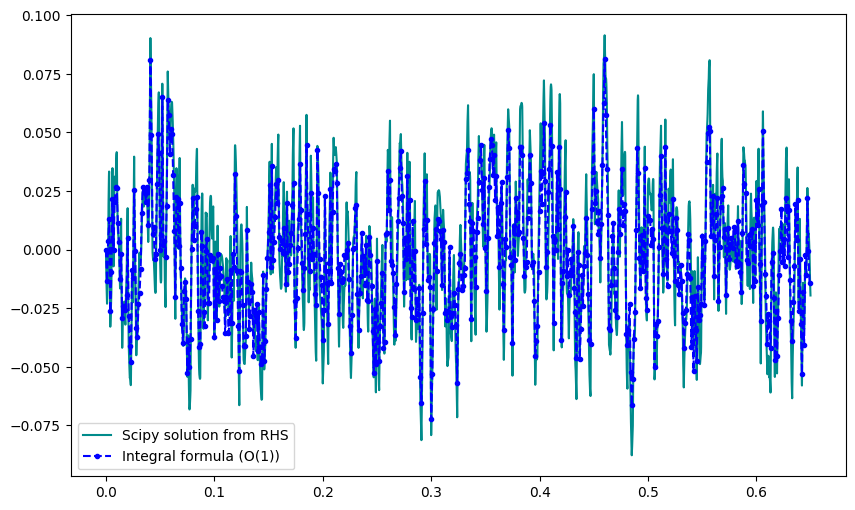

In [5]:
fig, ax = plt.subplots(figsize = (10,6))
ax.plot(tevD, solfpt[0, :], label = 'Scipy solution from RHS', color = 'darkcyan')

ax.plot(tev,anchorTraj[:,0],'.--', label = 'Integral formula (O(1))', color = 'blue')


ax.legend()

In [6]:
def calculate_A1(d, evals, eig):
    Ak = np.copy(evals[d:])
    Ak = Ak-eig
    return Ak



# Matrix P = [e1, ..., eN]
Sevals = np.flip(np.sort(evals))
P = evecs[:,np.flip(np.argsort(evals))]
P_inv = np.linalg.inv(P)

Qu = np.real(P_inv[0])

# A matrices
A10 = np.diag(calculate_A1( d, Sevals, Sevals[0]))
A20 = np.diag(calculate_A1( d, Sevals,2*Sevals[0]))
A30 = np.diag(calculate_A1( d, Sevals,3*Sevals[0]))
u1 = np.zeros(N)
u1[0]=1

# second derivatives
ddX = -2*np.divide(np.tanh(anchor_pt),np.power(np.cosh(anchor_pt),2))/tau1
d2fy2 = np.multiply(W,ddX)
d2fy2 = np.multiply(np.eye(N),np.tile(d2fy2[:,np.newaxis],(1,N,1)))

# third derivatives
dddX = np.divide(4*np.power(np.sinh(anchor_pt),2)-2,np.power(np.cosh(anchor_pt),4))/tau1
mat = np.multiply(W,dddX)
dH1 = np.multiply(np.eye(N),np.tile(mat[:,np.newaxis],(1,N,1)))
d3fy3 = np.multiply(np.eye(N),np.tile(dH1[:,np.newaxis],(1,N,1,1)))

# Order two autonomous coefficients 
h20 = - np.matmul(np.linalg.inv(A20), np.matmul(P_inv, np.dot(np.dot(d2fy2, np.matmul(P, u1)), np.matmul(P,u1)))[d:])

# Order three autonomous coefficients
h30 = - np.matmul(np.linalg.inv(A30), np.matmul(P_inv, np.dot(np.dot(np.dot(d3fy3, np.matmul(P, u1)), np.matmul(P,u1)),np.matmul(P,u1)) )[d:])



In [7]:
def f0(x,fp, tau = 0.01):
    return (np.matmul(W, np.tanh(x))- np.matmul(np.multiply(W,1/(np.cosh(fp)**2)), x))/tau
def ROM_u(t,u, fp, anchor,lambda1, t_in, tau1, dt1, *args, ):
    h11, h20 = args
    if np.shape(u)==(1,):
        u = u[0]
    if t_in!=0:
        t = t#+t_in*dt1
    k = int(t/(dt1))
    res = (lambda1*u + np.dot(Qu, f0(anchor[:,k]+fp+np.matmul(P, np.concatenate(([u],h11[:,k]*u*epsilon+ h20*u**2))), fp, tau=tau1)
                               -f0(anchor[:,k]+fp,fp, tau=tau1)))
    return (res)

In [8]:
from rnn_paper.SSMfunctions import construct_SSM1Dt,  calculate_H11_vectorized


In [9]:
h112 = calculate_H11_vectorized(N, d, Sevals, P, P_inv, d2fy2, solfpt, u1, nTimesteps, div = div, dt = dt,tau = tau1).T

In [10]:
s = sp.integrate.solve_ivp(RHS, [tevD[0],tevD[-1]], -anchor_pt,  t_eval = tevD,
                           args = (f1, anchor_pt, np.identity(N), np.identity(N), tau1,  dt)).y

In [11]:
#t0= 100*a 
t_in = 0
u0 = np.real(np.matmul(P_inv,s[:,div*t_in]-solfpt[:,div*t_in])[0])

u_sol = sp.integrate.solve_ivp(ROM_u, [tevD[div*t_in],tevD[-1]],[u0], \
                               args=( anchor_pt,solfpt, Sevals[0],  t_in, tau1,dt/div, h112, h20,),\
                                 t_eval = tevD[div*t_in:] ).y[0,:]
#u_sol = np.real(np.matmul(P_inv,(s[:,div*t_in:]-solfpt[:,div*t_in:]))[0])

/home/alice/RNN-paper/RNN-paper/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/base.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


In [12]:
u_vec = np.linspace(-1.2,1.2,70)


t_ev_dense_int = np.arange(0,len(tevD),1,dtype=int )# np.array([int(i) for i in t_ev_dense]) 

ssmt = (np.tensordot(P,construct_SSM1Dt(u_vec, t_ev_dense_int[:],epsilon, h112, h20, h30),axes = (1,0)))
Tssmt = np.real(ssmt + np.tile(np.expand_dims(solfpt[:,:], -1), (1,1,ssmt.shape[-1])))
rom_t = (np.dot(P,construct_SSM1Dt(u_sol[:], t_ev_dense_int[div*t_in:],epsilon, h112, h20, h30, surf = False),))
rom_t = rom_t+solfpt[:,div*t_in:]

In [13]:
X1,TT = np.meshgrid( u_vec,t_ev_dense_int[:])


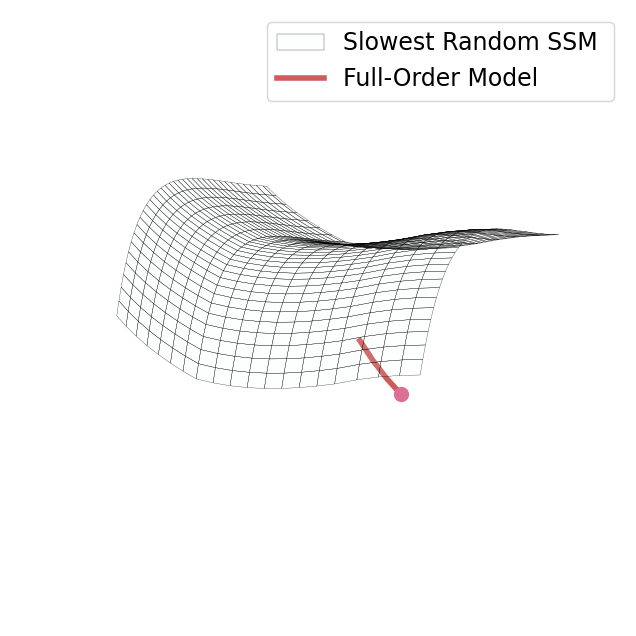

In [17]:
# make a gif

import matplotlib.animation as animation

m1 = 0#1
m2 = 12#11

figg = plt.figure(figsize = (8,8), dpi = 100)
axx_ = figg.add_subplot(projection = '3d',)
#figg.suptitle(r'Trajectory approaching the time-dependent Slowest SSM', fontsize = 17)

# animation of the solutions
anchor = [solfpt[m1], solfpt[m2]]
traj0 = [s[m1],s[m2]]
red_traj = [rom_t[m1],rom_t[m2]]


xl = [np.real(np.min(np.array(traj0)[0, div*(t_in):])), \
      np.real(np.max(np.array(traj0)[0, div*t_in:]))]
yl = [np.real(np.min(np.array(traj0)[1, div*t_in:])), \
      np.real(np.max(np.array(traj0)[1, div*t_in:]))]
#yl = [-0.2, 0.2]
#traj0 = [s[m1],-s[m2]]

t0= 5
tmax = t0+300 #1500
delta_t = 15

def animate(i):
        axx_.clear()
        pt_show=4
        axx_.plot_surface(TT[i-delta_t:i+delta_t-10]*dt,Tssmt[m1, i-delta_t:i+delta_t-10], Tssmt[m2,i-delta_t:i+delta_t-10],\
                                        color = 'mintcream',  edgecolors='k', lw=0.2, shade = False,label = r'Slowest Random SSM ', alpha =0.1)
        if i > div*10+pt_show:
                        axx_.plot(t_ev_dense_int[i-1]*dt,*np.array(red_traj)[:,i-div*t_in-1], '.', color = 'limegreen', markersize =20)

        #axx_.plot(t_ev_dense_int[i-1]*dt,*np.array(anchor)[:,i-1], '.', color = 'dodgerblue', markersize = 20)
        if i>pt_show+t0 or t0>pt_show:

                if i > div*10 +pt_show:
                        axx_.plot(t_ev_dense_int[i-pt_show:i]*dt,*np.array(red_traj)[:,i-div*t_in-pt_show:i-div*t_in], '-',linewidth = 6, color = 'mediumseagreen', label = 'Reduced-Order Model')
                #axx_.plot(t_ev_dense_int[i-pt_show:i]*dt,*np.array(anchor)[:,i-pt_show:i], '-', color = 'blue',linewidth = 4, alpha =1,label = r'Anchor Trajectory')
                axx_.plot(t_ev_dense_int[i-pt_show:i]*dt,*np.array(traj0)[:,i-pt_show:i], '-',linewidth = 4, color = 'indianred', alpha = 1, label = r'Full-Order Model')

        axx_.plot(t_ev_dense_int[i-1]*dt,*np.array(traj0)[:,i-1], '.', color = 'palevioletred', markersize = 20)

        if i <=pt_show+div*t0 and pt_show>div*t0: 
                print(i)
                axx_.plot(t_ev_dense_int[t0+i]*dt,*np.array(traj0)[:,t0+i], '-', color = 'darkred', alpha = 1)
                #axx_.plot(t_ev_dense_int[t0+i]*dt,*np.array(anchor)[:,t0+i], '-', color = 'blue', alpha =1)     
        
        axx_.legend(loc = 'upper right', fontsize = 17)
        #axx_.set_xlim((i-delta_t)*dt, (i+ delta_t-5)*dt)#*dt/div
        #axx_.set_ylim(xl)
        axx_.set_zlim(-.2)
        #axx_.set_xlabel(r'Time [msec]', fontsize = 13)
        #axx_.set_ylabel(r'$y_{%s}$'%(m1+1), fontsize =13)
        #axx_.set_zlabel(r'$y_{%s}$'%(m2+1), fontsize = 13)
        axx_.set_xticks([])
        axx_.set_zticks([])
        #axx_.set_yticks([])
        axx_.set_yticks([])
        axx_.set_axis_off()
        axx_.set_xlabel(r'Time [msec]', fontsize = 13)


        



axx_.set_xlabel('Time')
#axx_.set_ylabel(r'$y_{%s}$'%(m1+1))
#axx_.set_zlabel(r'$y_{%s}$'%(m2+1))

axx_.zaxis.set_rotate_label(False)  # disable automatic rotation
axx_.set_zlabel('label text', rotation=90)
axx_.set_xlim(t0*dt,tmax*dt)
#axx_.set_ylim(axx_.get_ylim())
#axx_.set_zlim(axx_.get_zlim())


axx_.view_init(30,-60,0)


anim = animation.FuncAnimation(figg, animate, frames=np.arange(t0*div,tmax,1), interval=30)

writevideo = animation.FFMpegWriter(fps=25) #25

#anim.save('video_t2d3d.mp4', writer=writevideo)